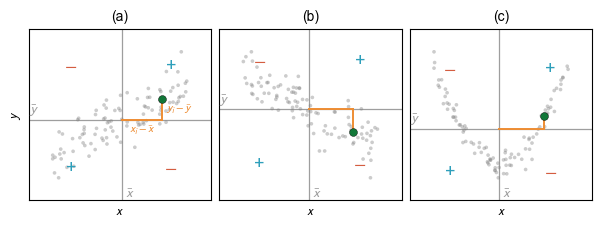

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ACCENT = "#117738"      # cor do ponto destacado
DESV = "#ee8d33"        # cor dos segmentos de desvio
MEAN = "#9e9e9e"        # linhas das medias
SINAL_P = "#2E9FBB"     # sinal positivo
SINAL_N = "#d45d40"     # sinal negativo
N_PTS = 100
SEED = 5
rng = np.random.default_rng(SEED)

lo, hi = -3, 3

xp = rng.uniform(lo, hi, N_PTS)
yp = 0.8 * xp + rng.normal(0, 0.9, N_PTS)
xn = rng.uniform(lo, hi, N_PTS)
yn = -0.8 * xn + rng.normal(0, 0.9, N_PTS)
xq = rng.uniform(lo, hi, N_PTS)
yq = 0.7 * xq**2 + rng.normal(0, 0.4, N_PTS)

plt.rcParams.update({"font.family": "Arial", "mathtext.fontset": "stixsans", "axes.titlesize": 10, "axes.labelsize": 9})

cm = 1/2.54
fig, axes = plt.subplots(1, 3, figsize=(15*cm, 5.5*cm), layout="constrained")


def moldura(ax, x, y, margem=0.18):
    """Define limites com folga e retorna os limites usados."""
    x0, x1 = x.min(), x.max()
    y0, y1 = y.min(), y.max()
    dx, dy = (x1 - x0) * margem, (y1 - y0) * margem
    ax.set_xlim(x0 - dx, x1 + dx)
    ax.set_ylim(y0 - dy, y1 + dy)
    return x0 - dx, x1 + dx, y0 - dy, y1 + dy


def sinais(ax, mx, my, xl0, xl1, yl0, yl1):
    """Sinais +/- centralizados em cada quadrante, sempre dentro do quadro."""
    xr = mx + (xl1 - mx) * 0.55      # centro do lado direito
    xe = mx - (mx - xl0) * 0.55      # centro do lado esquerdo
    ya = my + (yl1 - my) * 0.6       # centro da parte de cima
    yb = my - (my - yl0) * 0.6       # centro da parte de baixo
    ax.text(xr, ya, "+", color=SINAL_P, fontsize=13, ha="center", va="center")
    ax.text(xe, yb, "+", color=SINAL_P, fontsize=13, ha="center", va="center")
    ax.text(xe, ya, "$-$", color=SINAL_N, fontsize=13, ha="center", va="center")
    ax.text(xr, yb, "$-$", color=SINAL_N, fontsize=13, ha="center", va="center")


def desvio(ax, mx, my, xi, yi):
    ax.plot([mx, xi], [my, my], color=DESV, lw=1.4, zorder=3)
    ax.plot([xi, xi], [my, yi], color=DESV, lw=1.4, zorder=3)
    ax.scatter([xi], [yi], c=ACCENT, s=32, edgecolors="black", linewidth=0.3, zorder=4)


def media_labels(ax, mx, my, xl0, yl0, so_barra=True):
    """Marca x-barra e y-barra junto das linhas das medias."""
    ax.text(mx + 0.12, yl0, r"$\bar{x}$", color=MEAN, fontsize=10,
            ha="left", va="bottom")
    ax.text(xl0, my + 0.04, r"$\bar{y}$", color=MEAN, fontsize=10,
            ha="left", va="bottom")


# ---------------------------- Painel (a): positiva (chave) ---------------------
ax = axes[0]
mx, my = xp.mean(), yp.mean()
xl0, xl1, yl0, yl1 = moldura(ax, xp, yp)
ax.axvline(mx, color=MEAN, lw=0.9, zorder=1)
ax.axhline(my, color=MEAN, lw=0.9, zorder=1)
ax.scatter(xp, yp, c="gray", s=7, alpha=0.4, edgecolors="none", zorder=2)
sinais(ax, mx, my, xl0, xl1, yl0, yl1)
media_labels(ax, mx, my, xl0, yl0)
xi, yi = 1.9, 0.8 * 1.9
desvio(ax, mx, my, xi, yi)
ax.text((mx + xi) / 2, my - 0.28, r"$x_i - \bar{x}$", color=DESV, fontsize=8,
        ha="center", va="top")
ax.text(xi + 0.15, (my + yi) / 2, r"$y_i - \bar{y}$", color=DESV, fontsize=8,
        ha="left", va="center")
ax.set_title("(a)")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_xticks([])
ax.set_yticks([])

# ---------------------------- Painel (b): negativa -----------------------------
ax = axes[1]
mx, my = xn.mean(), yn.mean()
xl0, xl1, yl0, yl1 = moldura(ax, xn, yn)
ax.axvline(mx, color=MEAN, lw=0.9, zorder=1)
ax.axhline(my, color=MEAN, lw=0.9, zorder=1)
ax.scatter(xn, yn, c="gray", s=7, alpha=0.4, edgecolors="none", zorder=2)
sinais(ax, mx, my, xl0, xl1, yl0, yl1)
media_labels(ax, mx, my, xl0, yl0)
desvio(ax, mx, my, 1.9, -0.8 * 1.9)
ax.set_title("(b)")
ax.set_xlabel("$x$")
ax.set_xticks([])
ax.set_yticks([])

# ---------------------------- Painel (c): parabola (um ponto) ------------------
ax = axes[2]
mx, my = xq.mean(), yq.mean()
xl0, xl1, yl0, yl1 = moldura(ax, xq, yq)
ax.axvline(mx, color=MEAN, lw=0.9, zorder=1)
ax.axhline(my, color=MEAN, lw=0.9, zorder=1)
ax.scatter(xq, yq, c="gray", s=7, alpha=0.4, edgecolors="none", zorder=2)
sinais(ax, mx, my, xl0, xl1, yl0, yl1)
media_labels(ax, mx, my, xl0, yl0)
xa = 2.0
desvio(ax, mx, my, mx + xa, 0.7 * xa**2)
ax.set_title("(c)")
ax.set_xlabel("$x$")
ax.set_xticks([])
ax.set_yticks([])

fig.savefig("figuras/exemplo_pearson.png", dpi=300)

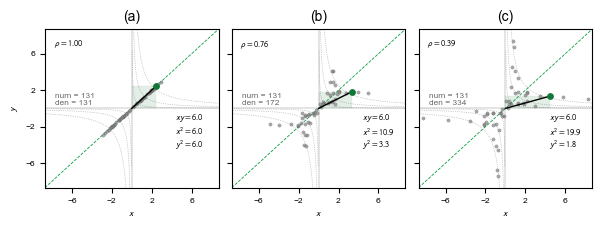

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stixsans",
    "axes.titlesize": 10,
    "axes.labelsize": 6.5,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6
})

cm = 1/2.54

VERDE = "#117738"
VERDE2 = "#099E42"

rng = np.random.default_rng(2)

m = 25
sp = rng.uniform(0.0, 3.0, m)
p = sp**2

z = rng.normal(0, 1, m)
z = z - z.mean()


def construir(s):
    t = np.exp(s * z)

    xr = sp * t
    yr = sp / t

    x = np.concatenate([xr, -xr])
    y = np.concatenate([yr, -yr])

    return x, y


ss = [0.0, 0.3, 0.6]
rotulos = ["(a)", "(b)", "(c)"]

p_rep = np.quantile(p, [0.15, 0.50, 0.85])

# ponto de referência com area fixa
p_ref = 6.0

# calcula os dados antes para fixar a mesma escala nos tres paineis
dados = [construir(s) for s in ss]

lim = 1.05 * max(
    max(
        np.abs(x).max(),
        np.abs(y).max(),
        np.sqrt(p_ref) * np.exp(s),
        np.sqrt(p_ref) / np.exp(s)
    )
    for (x, y), s in zip(dados, ss)
)

ticks = np.arange(-6, 7, 4)

fig, axes = plt.subplots(1, 3, figsize=(15*cm, 5.5*cm), layout="constrained", sharex=True, sharey=True)

axes[0].set_ylabel("$y$")

for ax, (x, y), s, rot in zip(axes, dados, ss, rotulos):

    num = np.sum(x * y)
    den = np.sqrt(np.sum(x**2) * np.sum(y**2))
    r = num / den

    # ----------------------------------------------------------
    # hiperboles
    # ----------------------------------------------------------

    xx = np.linspace(0.05, lim, 300)

    for pr in p_rep:
        ax.plot(
            xx,
            pr / xx,
            color="dimgray",
            lw=0.5,
            ls=":",
            alpha=0.6,
            zorder=0
        )

        ax.plot(
            -xx,
            -pr / xx,
            color="dimgray",
            lw=0.5,
            ls=":",
            alpha=0.6,
            zorder=0
        )

    # ----------------------------------------------------------
    # reta y=x
    # ----------------------------------------------------------

    ax.plot(
        [-lim, lim],
        [-lim, lim],
        color=VERDE2,
        lw=0.6,
        ls="--",
        zorder=1
    )

    # ----------------------------------------------------------
    # nuvem
    # ----------------------------------------------------------

    ax.scatter(
        x,
        y,
        c="gray",
        s=6,
        alpha=0.7,
        edgecolors="black",
        linewidth=0.1,
        zorder=2
    )

    # ----------------------------------------------------------
    # ponto de referencia com xy = 5.8
    # ----------------------------------------------------------

    t_ref = np.exp(s)
    xp = np.sqrt(p_ref) * t_ref
    yp = np.sqrt(p_ref) / t_ref

    ax.add_patch(
        plt.Rectangle(
            (0, 0),
            xp,
            yp,
            facecolor=VERDE,
            alpha=0.12,
            edgecolor=VERDE,
            lw=0.3,
            zorder=1
        )
    )

    ax.plot(
        [0, xp],
        [0, yp],
        color="black",
        lw=1.0,
        zorder=3
    )

    ax.scatter(
        [xp],
        [yp],
        color=VERDE,
        s=15,
        zorder=4
    )

    # ----------------------------------------------------------
    # estatisticas locais
    # ----------------------------------------------------------

    area = xp * yp
    x2= xp**2
    y2= yp**2
    diag2 = xp**2 + yp**2
    afast = (xp - yp)**2

    # ----------------------------------------------------------
    # eixos
    # ----------------------------------------------------------

    ax.axhline(0, color="gray", lw=0.3, zorder=0)
    ax.axvline(0, color="gray", lw=0.3, zorder=0)

    ax.set_title(rot)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.set_xlabel("$x$")

    # ----------------------------------------------------------
    # textos
    # ----------------------------------------------------------

    ax.text(
        0.05,
        0.94,
        f"$\\rho={r:.2f}$",
        transform=ax.transAxes,
        va="top",
        fontsize=6
    )

    ax.text(
        0.75,
        0.25,
        f"$xy={area:.1f}$\n$x^2={x2:.1f}$\n$y^2={y2:.1f}$",
        transform=ax.transAxes,
        fontsize=6
    )

    ax.text(
        0.06,
        0.52,
        f"num = {num:.0f}\nden = {den:.0f}",
        transform=ax.transAxes,
        fontsize=6,
        color="dimgray"
    )


plt.savefig("figuras/exemplo_pearson_denominador.png", dpi=300)
